## 0 — Imports & Seeds

In [1]:
import os
import csv
import random
import json
import shutil
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter, defaultdict
from tqdm import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1 — Mount Drive & Configuration

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# ── Paths ────────────────────────────────────────────────────────────────────
DATA_ROOT  = "/content/drive/MyDrive/ADNI/adni_nifti_preprocessed"
OUTPUT_DIR = "/content/drive/MyDrive/ADNI/preprocessed_alex"
CKPT_DIR   = "/content/drive/MyDrive/ADNI/checkpoints_alex"
os.makedirs(CKPT_DIR, exist_ok=True)

# ── Hyper-parameters ─────────────────────────────────────────────────────────
IMAGE_SIZE   = 224
N_FOLDS      = 5
BATCH_SIZE   = 32
NUM_EPOCHS   = 40
LR           = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE     = 10

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

VALID_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}

CLASS_NAMES = sorted([
    d for d in os.listdir(DATA_ROOT)
    if os.path.isdir(os.path.join(DATA_ROOT, d))
])
print(f"Classes found: {CLASS_NAMES}")

Mounted at /content/drive
Classes found: ['AD', 'CN', 'MCI']


## 2 — Build Patient Map & Leakage Check

In [3]:
patient_classes = defaultdict(set)
patient_slices  = defaultdict(list)

for cls in CLASS_NAMES:
    cls_dir = os.path.join(DATA_ROOT, cls)
    if not os.path.isdir(cls_dir):
        print(f"[WARNING] Missing class folder: {cls_dir}")
        continue
    for patient_id in os.listdir(cls_dir):
        patient_dir = os.path.join(cls_dir, patient_id)
        if not os.path.isdir(patient_dir):
            continue
        slices = [
            os.path.join(patient_dir, f)
            for f in os.listdir(patient_dir)
            if os.path.splitext(f)[1].lower() in VALID_EXTS
        ]
        if slices:
            patient_classes[patient_id].add(cls)
            patient_slices[(patient_id, cls)].extend(slices)

print(f"Total unique patients: {len(patient_classes)}")

# ── Leakage check ─────────────────────────────────────────────────────────────
leakage_patients = {
    pid: classes
    for pid, classes in patient_classes.items()
    if len(classes) > 1
}

print(f"\n{'='*55}")
print(f"  LEAKAGE CHECK")
print(f"{'='*55}")
if leakage_patients:
    print(f"  Patients in multiple classes (EXCLUDED): {len(leakage_patients)}")
    for pid, classes in sorted(leakage_patients.items()):
        print(f"    {pid}  ->  {sorted(classes)}")
else:
    print("  No patients in multiple classes. Dataset is clean.")

clean_patients = {
    pid: list(classes)[0]
    for pid, classes in patient_classes.items()
    if pid not in leakage_patients
}
print(f"\n  Patients kept    : {len(clean_patients)}")
print(f"  Patients excluded: {len(leakage_patients)}")

Total unique patients: 320

  LEAKAGE CHECK
  No patients in multiple classes. Dataset is clean.

  Patients kept    : 320
  Patients excluded: 0


## 3 — Hold-Out Test Set (Patient-Level, Stratified 15%)

In [4]:
TEST_RATIO = 0.15

class_patients = defaultdict(list)
for pid, cls in clean_patients.items():
    class_patients[cls].append(pid)

for cls in CLASS_NAMES:
    random.shuffle(class_patients[cls])

test_patients     = []
trainval_patients = []

print(f"{'='*55}")
print(f"  HOLD-OUT TEST SET (stratified by class)")
print(f"{'='*55}")

for cls in CLASS_NAMES:
    pids   = class_patients[cls]
    n_test = max(1, int(len(pids) * TEST_RATIO))
    test_patients.extend(pids[:n_test])
    trainval_patients.extend(pids[n_test:])
    print(f"  {cls}: {len(pids)} total  |  test={n_test}  |  train+val pool={len(pids)-n_test}")

assert not (set(test_patients) & set(trainval_patients)), "Test/trainval overlap!"
print(f"\n  Test patients     : {len(test_patients)}")
print(f"  Train+Val patients: {len(trainval_patients)}")
print(f"  Total             : {len(test_patients)+len(trainval_patients)}")

test_entries = []
for pid in test_patients:
    cls   = clean_patients[pid]
    label = CLASS_NAMES.index(cls)
    for path in patient_slices[(pid, cls)]:
        test_entries.append((path, label, pid))

print(f"  Test slices       : {len(test_entries)}")

  HOLD-OUT TEST SET (stratified by class)
  AD: 54 total  |  test=8  |  train+val pool=46
  CN: 88 total  |  test=13  |  train+val pool=75
  MCI: 178 total  |  test=26  |  train+val pool=152

  Test patients     : 47
  Train+Val patients: 273
  Total             : 320
  Test slices       : 1261


## 4 — Preprocess & Save All Slices to Disk

In [6]:
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_entries = []
for pid, cls in clean_patients.items():
    label = CLASS_NAMES.index(cls)
    for path in patient_slices[(pid, cls)]:
        all_entries.append((path, label, pid))

fname_counts = {}

def preprocess_and_save(entries, desc="Saving"):
    for path, label, pid in tqdm(entries, desc=desc):
        cls_name = CLASS_NAMES[label]
        out_dir  = os.path.join(OUTPUT_DIR, cls_name)
        os.makedirs(out_dir, exist_ok=True)

        base  = os.path.splitext(os.path.basename(path))[0]
        key   = f"{pid}_{base}"
        fname_counts[key] = fname_counts.get(key, 0) + 1
        suffix   = f"_dup{fname_counts[key]}" if fname_counts[key] > 1 else ""
        out_path = os.path.join(out_dir, f"{key}{suffix}.pt")

        if not os.path.exists(out_path):
            img    = Image.open(path).convert("L")
            img    = img.resize((IMAGE_SIZE, IMAGE_SIZE))
            tensor = transforms.ToTensor()(img)
            tensor = (tensor * 255).byte().repeat(3, 1, 1)
            torch.save(tensor, out_path)

preprocess_and_save(all_entries, desc="Preprocessing all slices")
print(f"Done. {len(all_entries)} slices saved to {OUTPUT_DIR}")

# ── Build pt_lookup from what is actually on disk ─────────────────────────────
pt_lookup = {}
for cls in CLASS_NAMES:
    cls_dir = os.path.join(OUTPUT_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    for fname in os.listdir(cls_dir):
        if fname.endswith(".pt"):
            stem = fname[:-3]
            pt_lookup[stem] = os.path.join(cls_dir, fname)

print(f"pt_lookup built: {len(pt_lookup)} entries")

Preprocessing all slices: 100%|██████████| 8512/8512 [1:00:49<00:00,  2.33it/s]

Done. 8512 slices saved to /content/drive/MyDrive/ADNI/preprocessed_alex
pt_lookup built: 8512 entries


## 5 — Dataset Class & Augmentation

In [7]:
normalize = transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

train_augment = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
])

class SliceDataset(Dataset):
    """
    Loads preprocessed .pt tensors for a given list of
    (path, label, patient_id) entries.
    Uses pt_lookup (built from disk) to handle _dupN suffixes correctly.
    """
    def __init__(self, entries, augment=False):
        self.samples = []
        self.augment = augment
        for path, label, pid in entries:
            cls_name = CLASS_NAMES[label]
            base     = os.path.splitext(os.path.basename(path))[0]
            key      = f"{pid}_{base}"

            if key in pt_lookup:
                self.samples.append((pt_lookup[key], label, pid))
            else:
                found = False
                for dup_idx in range(2, 50):
                    dup_key = f"{key}_dup{dup_idx}"
                    if dup_key in pt_lookup:
                        self.samples.append((pt_lookup[dup_key], label, pid))
                        found = True
                        break
                if not found:
                    pass

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        pt_path, label, pid = self.samples[idx]
        tensor = torch.load(pt_path, weights_only=True).float() / 255.0
        if self.augment:
            tensor = train_augment(tensor)
        return normalize(tensor), label, pid

    def get_labels(self): return [s[1] for s in self.samples]

print("SliceDataset class defined.")

SliceDataset class defined.


## 6 — Model Architecture

In [8]:
def build_alexnet_extractor():
    backbone = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

    backbone.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(9216, 512),
        nn.ReLU(inplace=True),
    )

    for param in backbone.parameters():
        param.requires_grad = False

    backbone.eval()
    return backbone

# ── FEAT_DIM must match the bottleneck output ─────────────────────────────────
FEAT_DIM = 512

ALEXNET_BACKBONE = build_alexnet_extractor().to(device)

total_params   = sum(p.numel() for p in ALEXNET_BACKBONE.parameters())
trainable_params = sum(p.numel() for p in ALEXNET_BACKBONE.parameters() if p.requires_grad)

print("AlexNet+SVM — reduced backbone ready.")
print(f"  Feature dimensionality : {FEAT_DIM}")
print(f"  Total backbone params  : {total_params:,}  (all frozen)")
print(f"  Trainable params       : {trainable_params:,}")
print(f"  SVM kernel             : RBF (trained per fold)")

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 173MB/s]


AlexNet+SVM — reduced backbone ready.
  Feature dimensionality : 512
  Total backbone params  : 7,188,800  (all frozen)
  Trainable params       : 0
  SVM kernel             : RBF (trained per fold)


## 7 — Training Utilities

In [9]:
@torch.no_grad()
def extract_features(loader, backbone, desc="Extracting features"):
    """
    Forward all slices through the frozen AlexNet backbone and collect
    the FEAT_DIM-d feature vectors together with labels and patient IDs.
    """
    backbone.eval()
    all_feats, all_labels, all_pids = [], [], []
    for images, labels, pids in tqdm(loader, desc=desc, leave=False):
        images = images.to(device, non_blocking=True)
        with torch.amp.autocast(device_type="cuda"):
            feats = backbone(images)
        all_feats.append(feats.cpu().float().numpy())
        all_labels.extend(labels.numpy().tolist())
        all_pids.extend(list(pids))
    return np.vstack(all_feats), np.array(all_labels), all_pids

def svm_patient_eval(loader, backbone, svm_clf, scaler):
    """
    Patient-level accuracy using soft slice voting:
      1. Extract backbone features for every slice.
      2. Scale with the fold's fitted StandardScaler.
      3. Average SVM predict_proba across all slices of a patient.
      4. argmax of averaged probabilities → patient prediction.
    """
    feats, labels, pids = extract_features(loader, backbone, desc="Patient-eval")
    feats_scaled = scaler.transform(feats)
    probs = svm_clf.predict_proba(feats_scaled)

    patient_probs  = defaultdict(list)
    patient_labels = {}
    for prob, label, pid in zip(probs, labels, pids):
        patient_probs[pid].append(prob)
        patient_labels[pid] = int(label)

    all_true, all_pred = [], []
    for pid, probs_list in patient_probs.items():
        avg_prob   = np.mean(probs_list, axis=0)
        pred_label = int(np.argmax(avg_prob))
        all_true.append(patient_labels[pid])
        all_pred.append(pred_label)

    acc = np.mean(np.array(all_true) == np.array(all_pred))
    return acc, all_true, all_pred

print("Training utilities defined (extract_features, svm_patient_eval).")

Training utilities defined (extract_features, svm_patient_eval).


## 8 — K-Fold Cross-Validation (Train+Val Pool)

In [10]:
import torch._dynamo
torch._dynamo.config.suppress_errors = True

trainval_by_class = defaultdict(list)
for pid in trainval_patients:
    trainval_by_class[clean_patients[pid]].append(pid)

for cls in CLASS_NAMES:
    random.shuffle(trainval_by_class[cls])

fold_results    = {cls: [] for cls in CLASS_NAMES}
all_fold_ckpts  = {cls: [] for cls in CLASS_NAMES}
all_fold_models = {cls: [] for cls in CLASS_NAMES}

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    print(f"\n{'='*65}")
    print(f"  {pos_name} vs REST  —  {N_FOLDS}-Fold Cross-Validation  (AlexNet+SVM)")
    print(f"{'='*65}")

    binary_names = ["REST", pos_name]

    class_folds = {}
    for cls in CLASS_NAMES:
        pids  = trainval_by_class[cls]
        folds = [pids[i::N_FOLDS] for i in range(N_FOLDS)]
        class_folds[cls] = folds

    for fold_idx in range(N_FOLDS):
        print(f"\n  --- Fold {fold_idx+1}/{N_FOLDS} ---")

        val_pids_fold = []
        for cls in CLASS_NAMES:
            val_pids_fold.extend(class_folds[cls][fold_idx])

        train_pids_fold = []
        for cls in CLASS_NAMES:
            for k, chunk in enumerate(class_folds[cls]):
                if k != fold_idx:
                    train_pids_fold.extend(chunk)

        def expand(pids):
            out = []
            for pid in pids:
                cls   = clean_patients[pid]
                label = CLASS_NAMES.index(cls)
                for path in patient_slices[(pid, cls)]:
                    out.append((path, label, pid))
            return out

        train_entries_fold = expand(train_pids_fold)
        val_entries_fold   = expand(val_pids_fold)

        def binarize(entries):
            return [(p, 1 if l == pos_class_idx else 0, pid)
                    for p, l, pid in entries]

        train_bin = binarize(train_entries_fold)
        val_bin   = binarize(val_entries_fold)

        train_ds = SliceDataset(train_bin, augment=False)
        val_ds   = SliceDataset(val_bin,   augment=False)

        pos_count = sum(1 for _, l, _ in train_bin if l == 1)
        neg_count = len(train_bin) - pos_count
        print(f"  Train slices — {pos_name}: {pos_count} | REST: {neg_count} | "
              f"Val patients: {len(val_pids_fold)}")

        if len(train_ds) == 0:
            raise RuntimeError(
                f"Fold {fold_idx+1} ({pos_name}): train_ds is empty! "
                f"Re-run Step 4 to rebuild the preprocessed cache."
            )

        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=4, pin_memory=True, persistent_workers=True)
        val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=4, pin_memory=True, persistent_workers=True)

        print("  Extracting AlexNet features from train slices...")
        train_feats, train_labels, _ = extract_features(
            train_loader, ALEXNET_BACKBONE, desc="  Train features"
        )

        scaler = StandardScaler()
        train_feats_scaled = scaler.fit_transform(train_feats)

        neg_w = (pos_count + neg_count) / (2.0 * neg_count)
        pos_w = (pos_count + neg_count) / (2.0 * pos_count)
        class_weight = {0: neg_w, 1: pos_w}

        print("  Training SVM (RBF kernel, probability=True)...")
        svm_clf = SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            probability=True,
            class_weight=class_weight,
            random_state=SEED,
        )
        svm_clf.fit(train_feats_scaled, train_labels)

        pat_acc, _, _ = svm_patient_eval(
            val_loader, ALEXNET_BACKBONE, svm_clf, scaler
        )
        print(f"  Fold {fold_idx+1} — Patient-level val acc: {pat_acc*100:.2f}%")

        ckpt_path = os.path.join(CKPT_DIR,
                                  f"fold{fold_idx+1}_{pos_name}_vs_rest_svm.pkl")
        joblib.dump({'svm': svm_clf, 'scaler': scaler}, ckpt_path)
        print(f"  Saved → {ckpt_path}")

        fold_results[pos_name].append(pat_acc)
        all_fold_ckpts[pos_name].append(ckpt_path)
        all_fold_models[pos_name].append((svm_clf, scaler))

        del train_ds, val_ds
        torch.cuda.empty_cache()

    mean_acc = np.mean(fold_results[pos_name]) * 100
    std_acc  = np.std(fold_results[pos_name])  * 100
    print(f"\n  {pos_name} vs REST — {N_FOLDS}-Fold CV Patient Acc: "
          f"{mean_acc:.2f}% ± {std_acc:.2f}%")

print("\n\nAll folds done.")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  AD vs REST  —  5-Fold Cross-Validation  (AlexNet+SVM)

  --- Fold 1/5 ---
  Train slices — AD: 957 | REST: 4851 | Val patients: 56
  Extracting AlexNet features from train slices...


  Train features:   0%|          | 0/182 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Training SVM (RBF kernel, probability=True)...


Patient-eval:   0%|          | 0/46 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rati

...

  Extracting AlexNet features from train slices...


  Train features:   0%|          | 0/182 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Training SVM (RBF kernel, probability=True)...


Patient-eval:   0%|          | 0/46 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  Fold 5 — Patient-level val acc: 57.41%
  Saved → /content/drive/MyDrive/ADNI/checkpoints_alex/fold5_MCI_vs_rest_svm.pkl

  MCI vs REST — 5-Fold CV Patient Acc: 54.25% ± 4.64%


All folds done.


## 9 — Weighted Ensemble Evaluation on Hold-Out Test Set

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


  WEIGHTED ENSEMBLE — HOLD-OUT TEST EVALUATION (Patient-Level)
  Model: AlexNet + SVM  (Mohammed et al. 2021)

  AD vs REST
    Fold 1: val_acc=80.36%  weight=0.1958
    Fold 2: val_acc=80.00%  weight=0.1950
    Fold 3: val_acc=83.33%  weight=0.2031
    Fold 4: val_acc=85.19%  weight=0.2076
    Fold 5: val_acc=81.48%  weight=0.1986
  Extracting AlexNet features for test set...


AD — Test features:   0%|          | 0/40 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  Weighted Ensemble Test Acc (AD vs REST): 82.98%  [47 patients]
              precision    recall  f1-score   support

        REST       0.84      0.97      0.90        39
          AD       0.50      0.12      0.20         8

    accuracy                           0.83        47
   macro avg       0.67      0.55      0.55        47
weighted avg       0.79      0.83      0.78        47



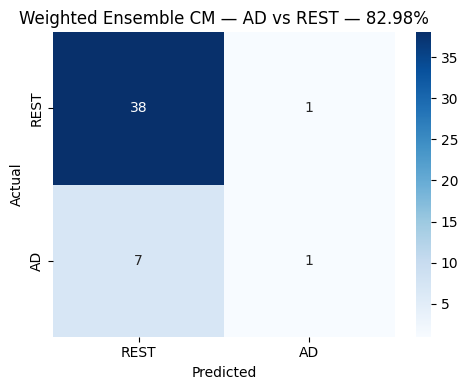

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  CN vs REST
    Fold 1: val_acc=73.21%  weight=0.2008
    Fold 2: val_acc=69.09%  weight=0.1895
    Fold 3: val_acc=79.63%  weight=0.2184
    Fold 4: val_acc=72.22%  weight=0.1981
    Fold 5: val_acc=70.37%  weight=0.1930
  Extracting AlexNet features for test set...


CN — Test features:   0%|          | 0/40 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  Weighted Ensemble Test Acc (CN vs REST): 74.47%  [47 patients]
              precision    recall  f1-score   support

        REST       0.76      0.94      0.84        34
          CN       0.60      0.23      0.33        13

    accuracy                           0.74        47
   macro avg       0.68      0.59      0.59        47
weighted avg       0.72      0.74      0.70        47



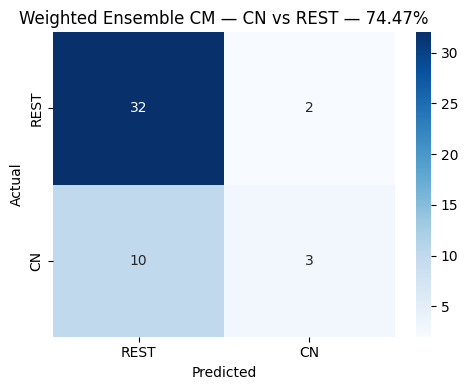

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  MCI vs REST
    Fold 1: val_acc=53.57%  weight=0.1975
    Fold 2: val_acc=45.45%  weight=0.1676
    Fold 3: val_acc=57.41%  weight=0.2116
    Fold 4: val_acc=57.41%  weight=0.2116
    Fold 5: val_acc=57.41%  weight=0.2116
  Extracting AlexNet features for test set...


MCI — Test features:   0%|          | 0/40 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



  Weighted Ensemble Test Acc (MCI vs REST): 59.57%  [47 patients]
              precision    recall  f1-score   support

        REST       0.57      0.38      0.46        21
         MCI       0.61      0.77      0.68        26

    accuracy                           0.60        47
   macro avg       0.59      0.58      0.57        47
weighted avg       0.59      0.60      0.58        47



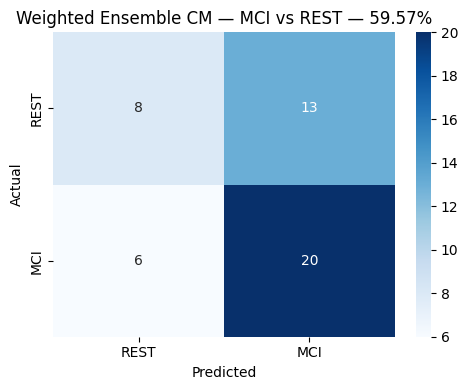

In [11]:
print(f"{'='*65}")
print(f"  WEIGHTED ENSEMBLE — HOLD-OUT TEST EVALUATION (Patient-Level)")
print(f"  Model: AlexNet + SVM  (Mohammed et al. 2021)")
print(f"{'='*65}")

final_results = {}

for pos_class_idx, pos_name in enumerate(CLASS_NAMES):
    binary_names = ["REST", pos_name]

    test_bin = [
        (p, 1 if l == pos_class_idx else 0, pid)
        for p, l, pid in test_entries
    ]
    test_ds     = SliceDataset(test_bin, augment=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=4, pin_memory=True, persistent_workers=True)

    fold_accs    = np.array(fold_results[pos_name])
    fold_weights = fold_accs / fold_accs.sum()

    print(f"\n  {pos_name} vs REST")
    for fi, (acc, w) in enumerate(zip(fold_accs, fold_weights)):
        print(f"    Fold {fi+1}: val_acc={acc*100:.2f}%  weight={w:.4f}")

    print(f"  Extracting AlexNet features for test set...")
    test_feats, test_labels_arr, test_pids = extract_features(
        test_loader, ALEXNET_BACKBONE, desc=f"{pos_name} — Test features"
    )

    weighted_probs = np.zeros((len(test_feats), 2))
    for (svm_clf, scaler), w in zip(all_fold_models[pos_name], fold_weights):
        feats_scaled  = scaler.transform(test_feats)
        probs         = svm_clf.predict_proba(feats_scaled)
        weighted_probs += w * probs

    patient_probs  = defaultdict(lambda: np.zeros(2))
    patient_labels = {}
    for wp, label, pid in zip(weighted_probs, test_labels_arr, test_pids):
        patient_probs[pid]  += wp
        patient_labels[pid]  = int(label)

    all_true, all_pred = [], []
    for pid, wp_sum in patient_probs.items():
        all_true.append(patient_labels[pid])
        all_pred.append(int(np.argmax(wp_sum)))

    pat_acc = np.mean(np.array(all_true) == np.array(all_pred))

    print(f"\n  Weighted Ensemble Test Acc ({pos_name} vs REST): "
          f"{pat_acc*100:.2f}%  [{len(patient_probs)} patients]")
    print(classification_report(all_true, all_pred, target_names=binary_names))

    cm = confusion_matrix(all_true, all_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=binary_names, yticklabels=binary_names)
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title(f"Weighted Ensemble CM — {pos_name} vs REST — {pat_acc*100:.2f}%")
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, f"cm_ensemble_{pos_name}_vs_rest.png"), dpi=150)
    plt.show()

    final_results[pos_name] = {
        "patient_test_acc": pat_acc,
        "cv_mean_acc":      float(np.mean(fold_accs)),
        "cv_std_acc":       float(np.std(fold_accs)),
        "fold_weights":     fold_weights.tolist(),
    }

    del test_ds
    torch.cuda.empty_cache()

## 10 — Summary & Save Results

In [12]:
print(f"\n{'='*65}")
print(f"  FINAL SUMMARY — WEIGHTED ENSEMBLE")
print(f"{'='*65}")
print(f"  {'Class':<8} {'CV Acc (mean±std)':<24} {'Ensemble Test Acc (patient-level)'}")
print(f"  {'-'*65}")

for cls, res in final_results.items():
    cv_str   = f"{res['cv_mean_acc']*100:.2f}% ± {res['cv_std_acc']*100:.2f}%"
    test_str = f"{res['patient_test_acc']*100:.2f}%"
    print(f"  {cls:<8} {cv_str:<24} {test_str}")

csv_path = os.path.join(CKPT_DIR, "results_weighted_ensemble.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=[
        "class", "cv_mean_acc_%", "cv_std_%", "ensemble_test_acc_%", "fold_weights"
    ])
    writer.writeheader()
    for cls, res in final_results.items():
        writer.writerow({
            "class":               cls,
            "cv_mean_acc_%":       round(res["cv_mean_acc"] * 100, 2),
            "cv_std_%":            round(res["cv_std_acc"]  * 100, 2),
            "ensemble_test_acc_%": round(res["patient_test_acc"] * 100, 2),
            "fold_weights":        str([round(w, 4) for w in res["fold_weights"]]),
        })

print(f"\n  Results saved -> {csv_path}")


  FINAL SUMMARY — WEIGHTED ENSEMBLE
  Class    CV Acc (mean±std)        Ensemble Test Acc (patient-level)
  -----------------------------------------------------------------
  AD       82.07% ± 1.94%           82.98%
  CN       72.91% ± 3.65%           74.47%
  MCI      54.25% ± 4.64%           59.57%

  Results saved -> /content/drive/MyDrive/ADNI/checkpoints_alex/results_weighted_ensemble.csv


In [13]:
torch.save(ALEXNET_BACKBONE.state_dict(), os.path.join(CKPT_DIR, "alexnet_backbone_state_dict.pt"))
print(f"AlexNet backbone state dict saved to: {os.path.join(CKPT_DIR, 'alexnet_backbone_state_dict.pt')}")

joblib.dump(all_fold_models, os.path.join(CKPT_DIR, "all_svm_models_and_scalers.pkl"))
print(f"All SVM models and scalers consolidated and saved to: {os.path.join(CKPT_DIR, 'all_svm_models_and_scalers.pkl')}")

AlexNet backbone state dict saved to: /content/drive/MyDrive/ADNI/checkpoints_alex/alexnet_backbone_state_dict.pt
All SVM models and scalers consolidated and saved to: /content/drive/MyDrive/ADNI/checkpoints_alex/all_svm_models_and_scalers.pkl


##Xai techniques

In [27]:
!pip install shap

In [28]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import cv2

from lime import lime_image
from skimage.segmentation import mark_boundaries

import shap

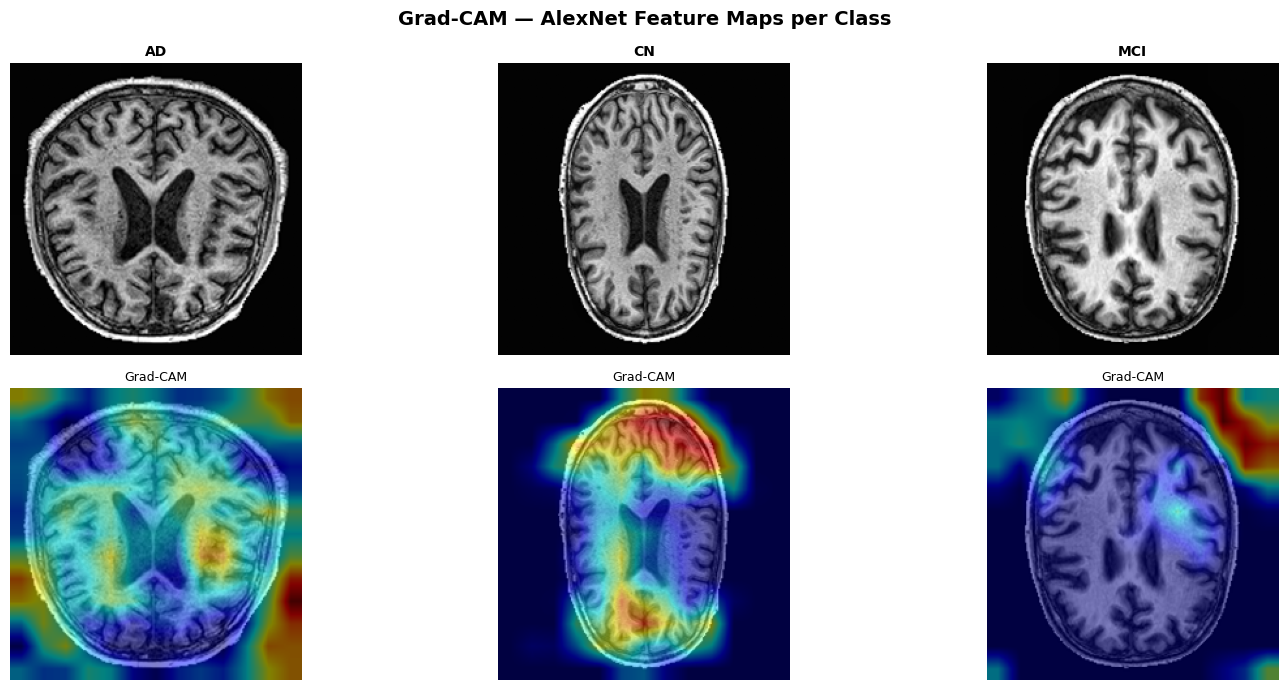

In [21]:
def build_alexnet_gradcam_classifier(num_classes):
    backbone = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

    for param in backbone.parameters():
        param.requires_grad = False
    for param in backbone.features[10].parameters():
        param.requires_grad = True
    for param in backbone.features[11].parameters():
        param.requires_grad = True

    backbone.classifier = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(9216, 512),
        nn.ReLU(inplace=True),
        nn.Linear(512, num_classes)
    )

    for param in backbone.classifier.parameters():
        param.requires_grad = True

    return backbone.to(device)

gradcam_model  = build_alexnet_gradcam_classifier(num_classes=len(CLASS_NAMES))
gradcam_model.eval()

target_layer   = [gradcam_model.features[10]]
cam = GradCAM(model=gradcam_model, target_layers=target_layer)

fig, axes = plt.subplots(2, len(CLASS_NAMES), figsize=(16, 7))
fig.suptitle("Grad-CAM — AlexNet Feature Maps per Class", fontsize=14, fontweight='bold')

for idx, (cls_name, label) in enumerate(zip(CLASS_NAMES, range(len(CLASS_NAMES)))):

    sample_entry = next(
        (e for e in test_entries if e[1] == label), None)
    if sample_entry is None:
        print(f"[WARNING] No test slice found for class {cls_name}")
        continue

    path, lbl, pid = sample_entry
    img_pil = Image.open(path).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))

    img_tensor = transforms.ToTensor()(img_pil)
    img_tensor = img_tensor.repeat(3, 1, 1)
    input_tensor = normalize(img_tensor).unsqueeze(0).to(device)

    img_np_display = np.stack([np.array(img_pil)] * 3, axis=-1).astype(np.float32) / 255.0

    with torch.no_grad():
        output_logits = gradcam_model(input_tensor)
        predicted_class_idx = torch.argmax(output_logits, dim=1).item()

    targets = [ClassifierOutputTarget(label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    cam_image     = show_cam_on_image(img_np_display, grayscale_cam, use_rgb=True)

    axes[0][idx].imshow(img_np_display)
    axes[0][idx].set_title(cls_name, fontsize=10, fontweight='bold')
    axes[0][idx].axis('off')

    axes[1][idx].imshow(cam_image)
    axes[1][idx].set_title('Grad-CAM', fontsize=9)
    axes[1][idx].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "alex_gradcam.png"), dpi=150)
plt.show()

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

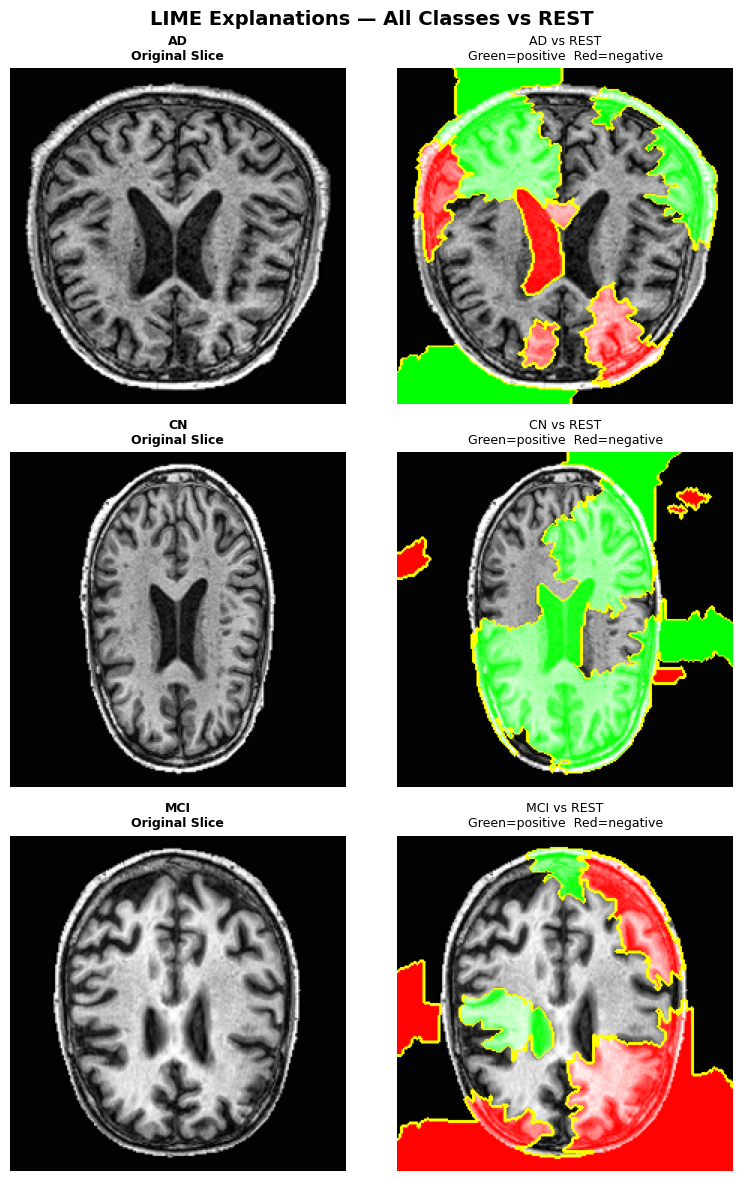

In [26]:
fig, axes = plt.subplots(len(CLASS_NAMES), 2, figsize=(8, len(CLASS_NAMES) * 4))
fig.suptitle("LIME Explanations — All Classes vs REST", fontsize=14, fontweight='bold')

for idx, (pos_name_lime, pos_class_idx) in enumerate(zip(CLASS_NAMES, range(len(CLASS_NAMES)))):

    svm_clf_lime, scaler_lime = all_fold_models[pos_name_lime][0]

    def lime_predict_fn(images_np):
        batch = []
        for img in images_np:
            pil = Image.fromarray(img).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))
            t   = normalize(transforms.ToTensor()(pil).repeat(3, 1, 1))
            batch.append(t)
        batch_tensor = torch.stack(batch).to(device)
        with torch.no_grad():
            feats = ALEXNET_BACKBONE(batch_tensor).cpu().numpy()
        feats_scaled = scaler_lime.transform(feats)
        return svm_clf_lime.predict_proba(feats_scaled)

    sample_entry = next((e for e in test_entries if e[1] == pos_class_idx), None)
    if sample_entry is None:
        print(f"[WARNING] No test slice for {pos_name_lime}")
        continue

    path, lbl, pid = sample_entry
    img_pil   = Image.open(path).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))
    img_rgb_l = np.stack([np.array(img_pil)] * 3, axis=-1).astype(np.float32) / 255.0
    img_uint8 = (img_rgb_l * 255).astype(np.uint8)

    explainer_lime = lime_image.LimeImageExplainer(random_state=SEED)
    explanation    = explainer_lime.explain_instance(
        img_uint8,
        lime_predict_fn,
        top_labels=2,
        hide_color=0,
        num_samples=500,
        random_seed=SEED,
    )

    lime_img, mask = explanation.get_image_and_mask(
        label=1,
        positive_only=False,
        num_features=10,
        hide_rest=False,
    )

    axes[idx][0].imshow(img_uint8)
    axes[idx][0].set_title(f"{pos_name_lime}\nOriginal Slice", fontsize=9, fontweight='bold')
    axes[idx][0].axis('off')

    axes[idx][1].imshow(mark_boundaries(lime_img, mask))
    axes[idx][1].set_title(f"{pos_name_lime} vs REST\nGreen=positive  Red=negative", fontsize=9)
    axes[idx][1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "xai_lime_all_classes.png"), dpi=150)
plt.show()


  SHAP — AD vs REST


  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_12643/1829496292.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


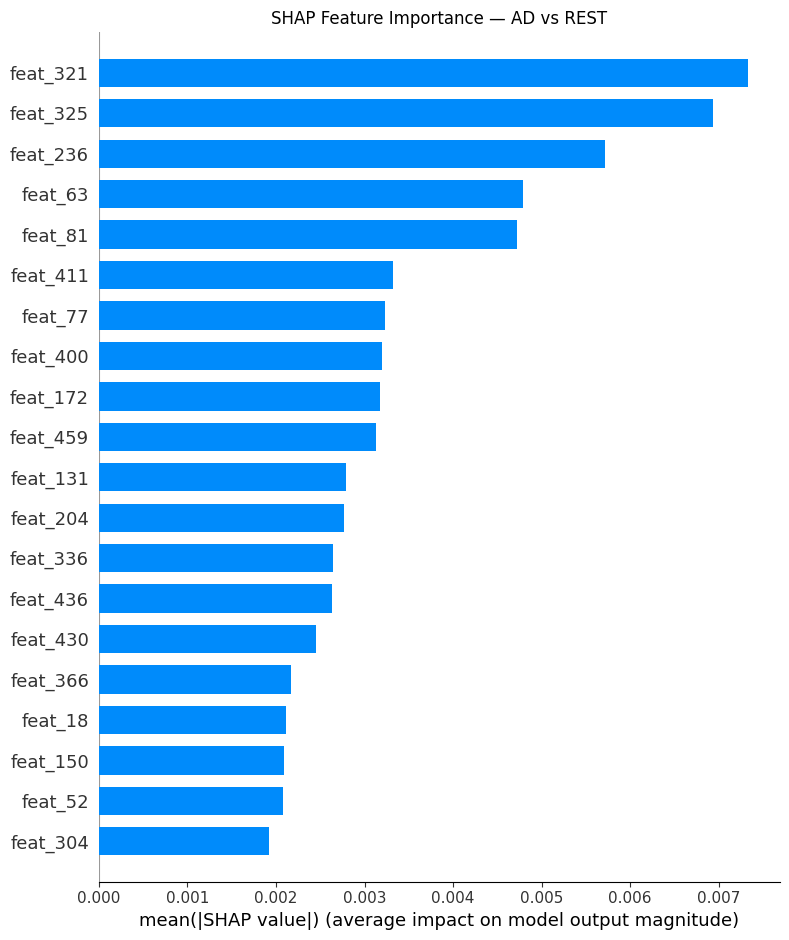

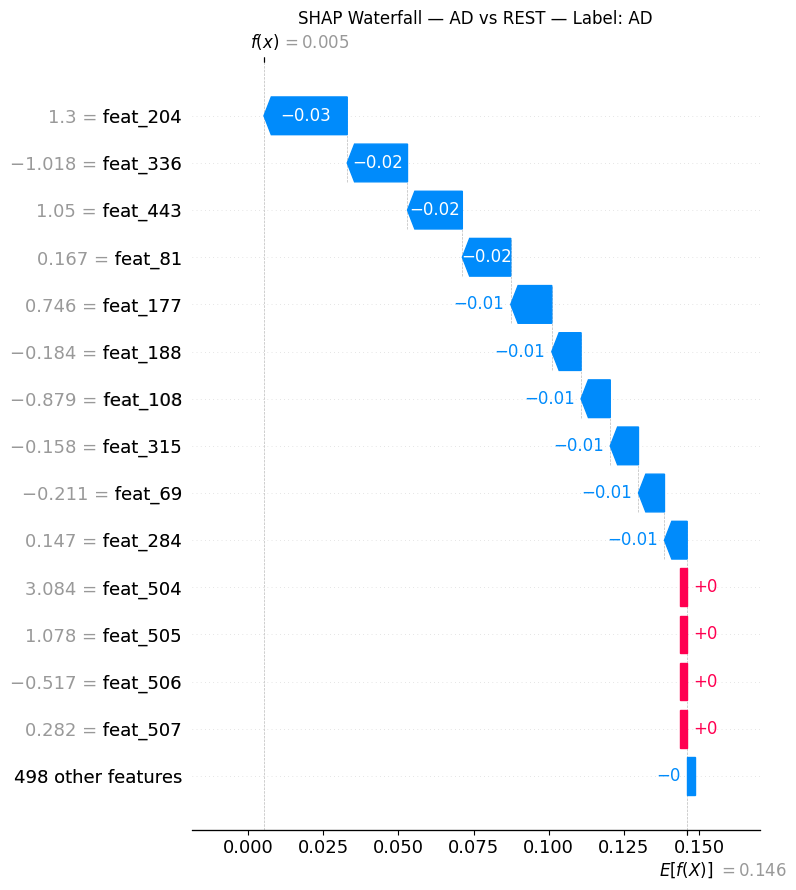


  SHAP — CN vs REST


  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_12643/1829496292.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


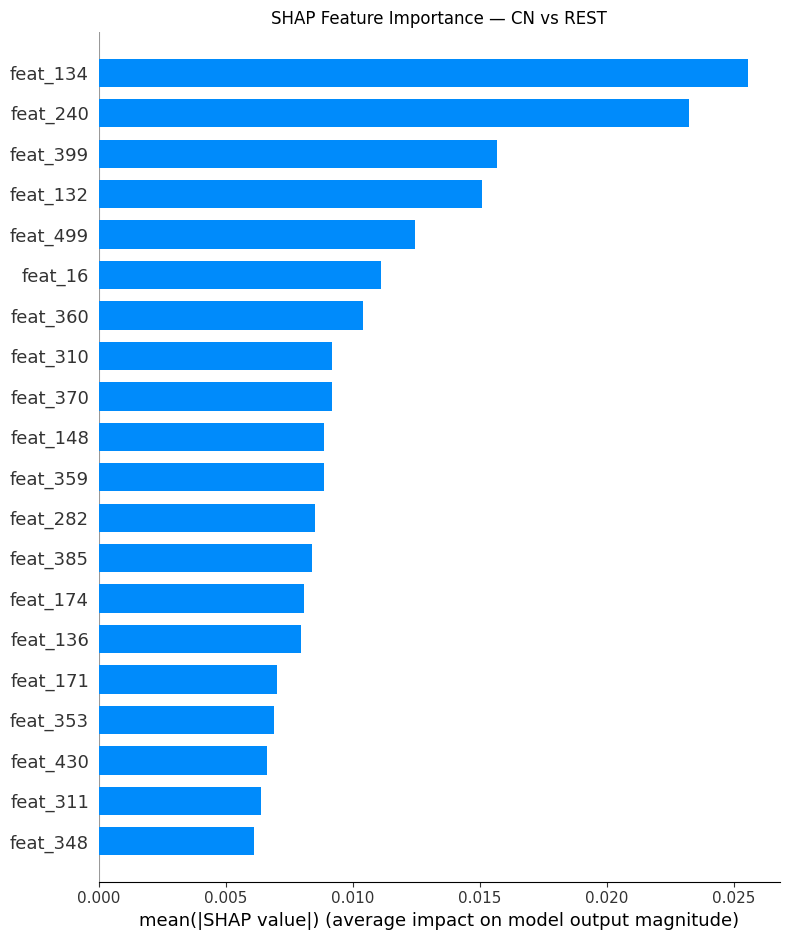

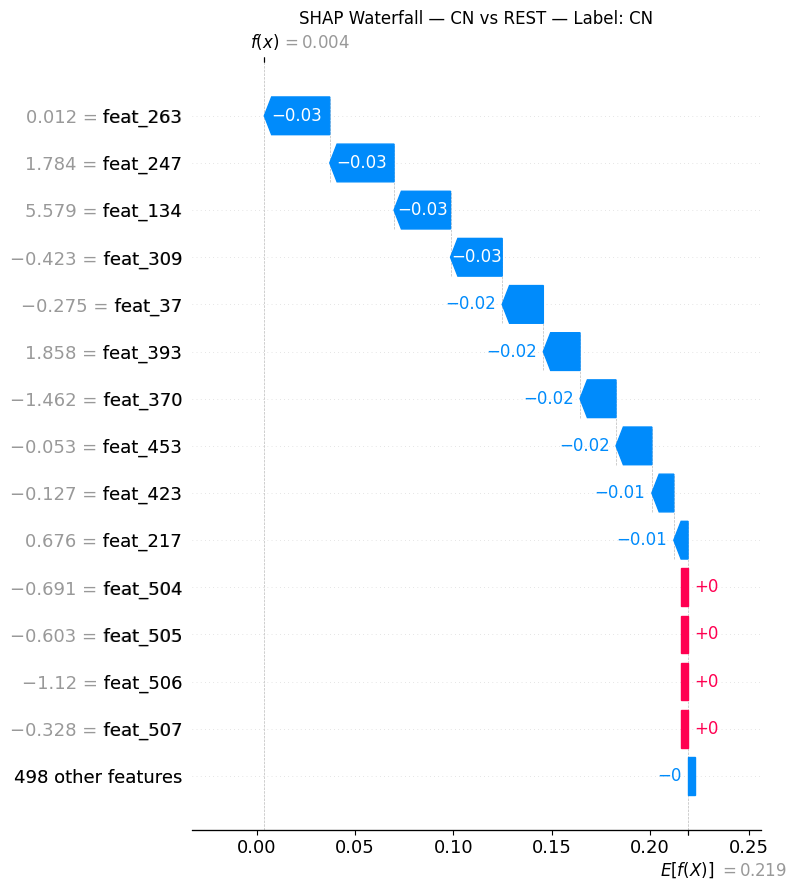


  SHAP — MCI vs REST


  0%|          | 0/10 [00:00<?, ?it/s]

/tmp/ipykernel_12643/1829496292.py:30: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


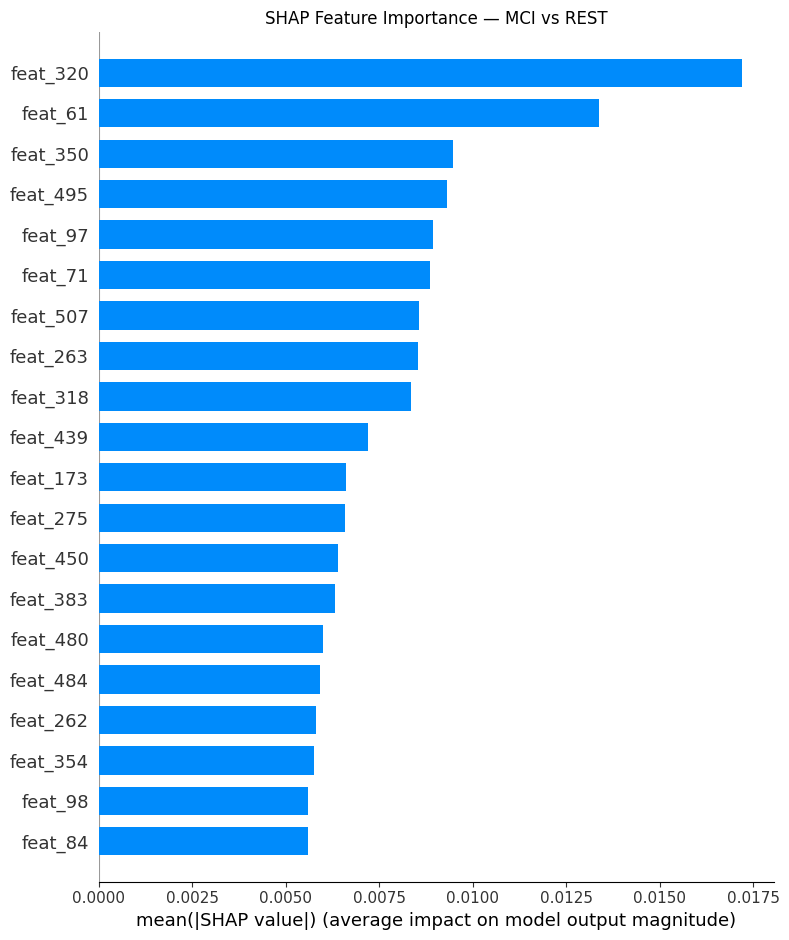

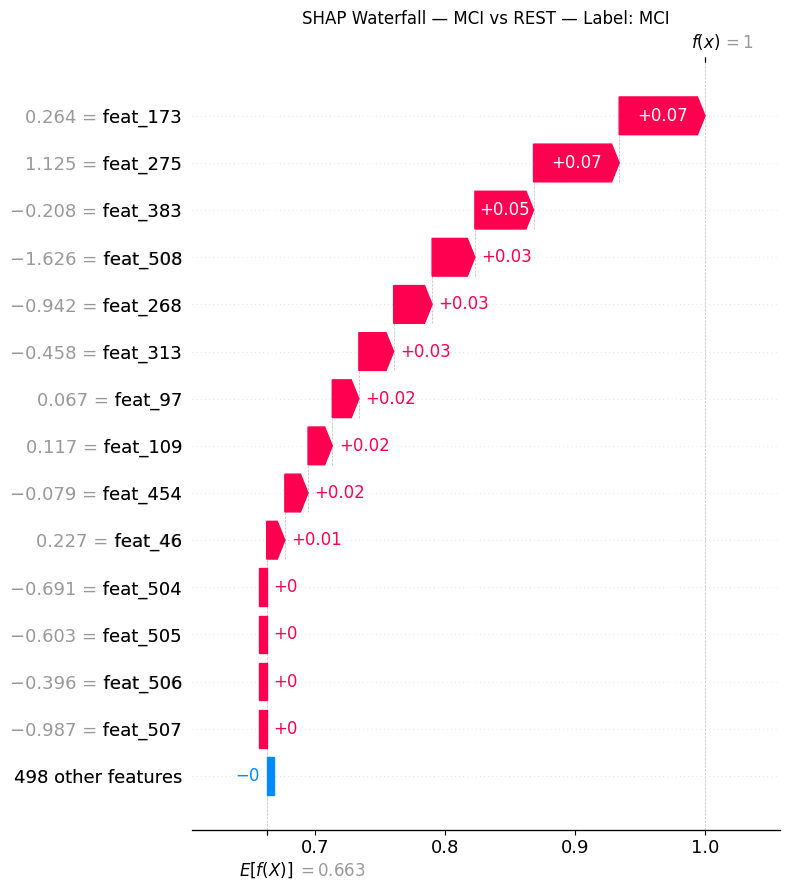

In [31]:
for pos_name_shap, pos_class_idx in zip(CLASS_NAMES, range(len(CLASS_NAMES))):

    print(f"\n  SHAP — {pos_name_shap} vs REST")
    svm_clf_shap, scaler_shap = all_fold_models[pos_name_shap][0]

    bg_entries = (
        [e for e in test_entries if e[1] == pos_class_idx][:50] +
        [e for e in test_entries if e[1] != pos_class_idx][:50])
    bg_ds = SliceDataset([(p, l, pid) for p, l, pid in bg_entries], augment=False)
    bg_loader = DataLoader(bg_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    bg_feats, _, _ = extract_features(bg_loader, ALEXNET_BACKBONE, desc=f"  BG features [{pos_name_shap}]")
    bg_feats_scaled = scaler_shap.transform(bg_feats)

    explain_entries = [e for e in test_entries if e[1] == pos_class_idx][:10]
    if len(explain_entries) == 0:
        print(f"  [WARNING] No test slices for {pos_name_shap}, skipping.")
        continue
    exp_ds  = SliceDataset([(p, l, pid) for p, l, pid in explain_entries], augment=False)
    exp_loader = DataLoader(exp_ds, batch_size=len(explain_entries), shuffle=False, num_workers=2)
    exp_feats, exp_labels, _ = extract_features(exp_loader, ALEXNET_BACKBONE, desc=f"  EXP features [{pos_name_shap}]")
    exp_feats_scaled = scaler_shap.transform(exp_feats)

    def shap_predict(X):
        return svm_clf_shap.predict_proba(X)[:, 1]

    kernel_explainer = shap.KernelExplainer(shap_predict, bg_feats_scaled)
    shap_values = kernel_explainer.shap_values(exp_feats_scaled, nsamples=200)

    plt.figure()
    shap.summary_plot(
        shap_values, exp_feats_scaled,
        feature_names=[f"feat_{i}" for i in range(FEAT_DIM)],
        max_display=20, show=False,
        plot_type="bar",)
    plt.title(f"SHAP Feature Importance — {pos_name_shap} vs REST")
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, f"xai_shap_summary_{pos_name_shap}.png"), dpi=150)
    plt.show()

    shap.plots.waterfall(
        shap.Explanation(
            values        = shap_values[0],
            base_values   = kernel_explainer.expected_value,
            data          = exp_feats_scaled[0],
            feature_names = [f"feat_{i}" for i in range(FEAT_DIM)],),
        max_display=15, show=False,)
    plt.title(f"SHAP Waterfall — {pos_name_shap} vs REST — Label: {CLASS_NAMES[exp_labels[0]]}")
    plt.tight_layout()
    plt.savefig(os.path.join(CKPT_DIR, f"alex_shap_waterfall_{pos_name_shap}.png"), dpi=150)
    plt.show()

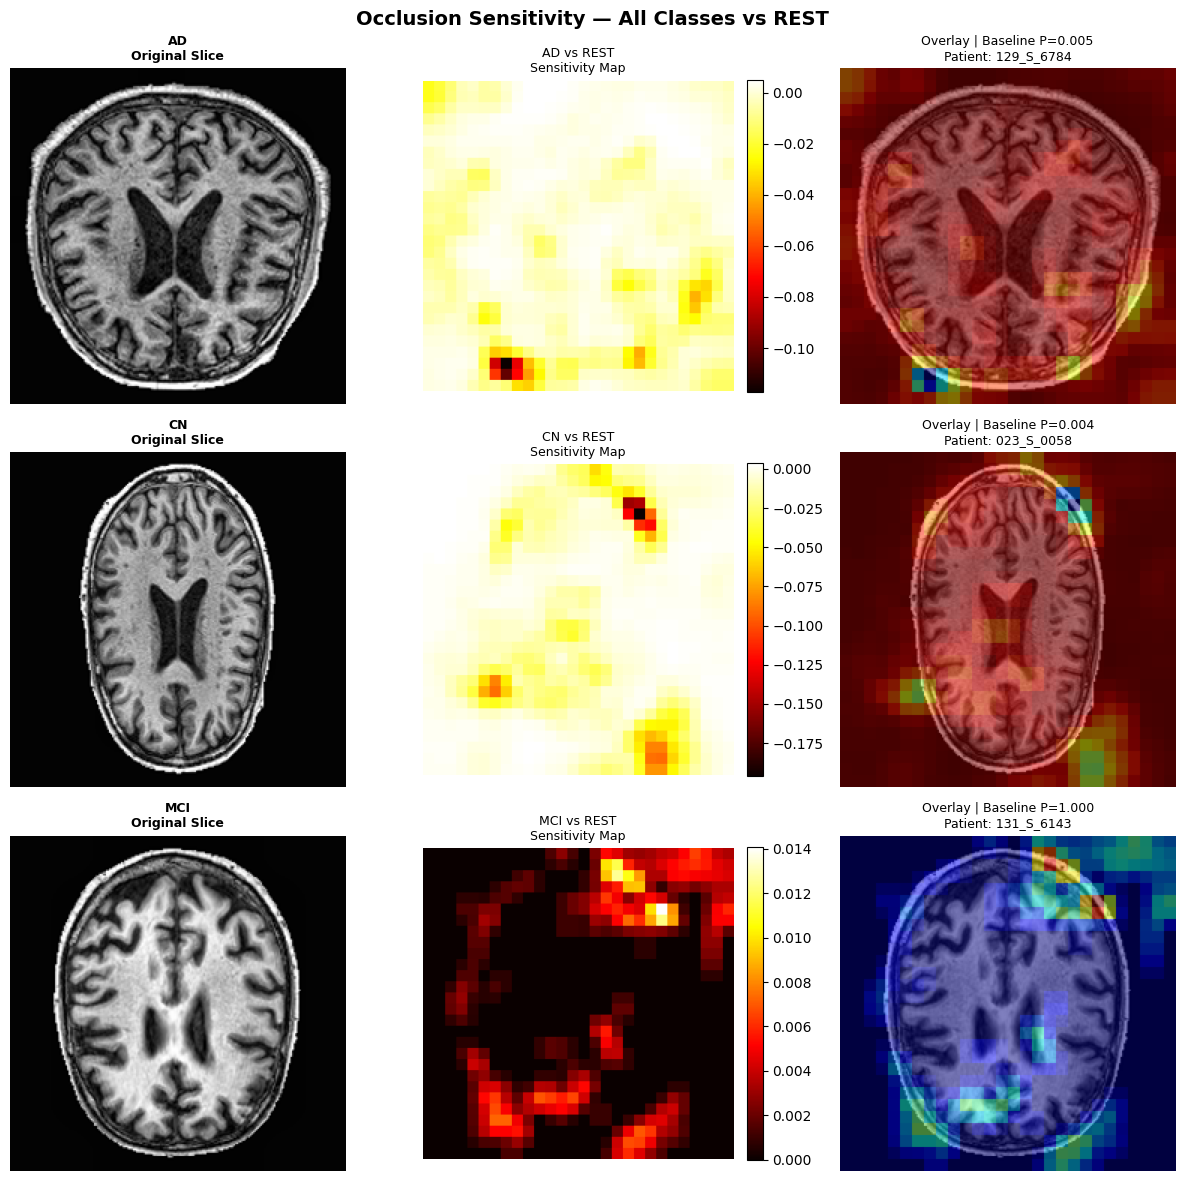

In [36]:
def occlusion_sensitivity(image_tensor, backbone, svm_clf, scaler, patch_size=16, stride=8, occlude_value=0.0):
    C, H, W  = image_tensor.shape
    sens_map = np.zeros((H, W), dtype=np.float32)
    count    = np.zeros((H, W), dtype=np.float32)

    with torch.no_grad():
        base_feat = backbone(image_tensor.unsqueeze(0).to(device)).cpu().numpy()
    base_prob = svm_clf.predict_proba(scaler.transform(base_feat))[0, 1]

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            occluded = image_tensor.clone()
            occluded[:, y:y+patch_size, x:x+patch_size] = occlude_value
            with torch.no_grad():
                occ_feat = backbone(occluded.unsqueeze(0).to(device)).cpu().numpy()
            occ_prob = svm_clf.predict_proba(scaler.transform(occ_feat))[0, 1]
            drop = base_prob - occ_prob
            sens_map[y:y+patch_size, x:x+patch_size] += drop
            count   [y:y+patch_size, x:x+patch_size] += 1

    sens_map /= np.maximum(count, 1)
    return sens_map, base_prob

fig, axes = plt.subplots(len(CLASS_NAMES), 3, figsize=(12, len(CLASS_NAMES) * 4))
fig.suptitle("Occlusion Sensitivity — All Classes vs REST", fontsize=14, fontweight='bold')

for idx, (pos_name_occ, pos_class_idx) in enumerate(zip(CLASS_NAMES, range(len(CLASS_NAMES)))):

    svm_clf_occ, scaler_occ = all_fold_models[pos_name_occ][0]

    sample_entry = next((e for e in test_entries if e[1] == pos_class_idx), None)
    if sample_entry is None:
        print(f"[WARNING] No test slice for {pos_name_occ}, skipping.")
        continue

    path, lbl, pid = sample_entry
    img_pil  = Image.open(path).convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))
    img_rgb  = np.stack([np.array(img_pil)] * 3, axis=-1).astype(np.float32) / 255.0
    img_tensor = normalize(transforms.ToTensor()(img_pil).repeat(3, 1, 1))

    sens_map, base_prob = occlusion_sensitivity(
        img_tensor, ALEXNET_BACKBONE, svm_clf_occ, scaler_occ,
        patch_size=16, stride=8,
    )
    sens_norm = (sens_map - sens_map.min()) / (sens_map.max() - sens_map.min() + 1e-8)

    axes[idx][0].imshow(img_rgb)
    axes[idx][0].set_title(f"{pos_name_occ}\nOriginal Slice", fontsize=9, fontweight='bold')
    axes[idx][0].axis('off')

    im = axes[idx][1].imshow(sens_map, cmap="hot")
    axes[idx][1].set_title(f"{pos_name_occ} vs REST\nSensitivity Map", fontsize=9)
    axes[idx][1].axis('off')
    plt.colorbar(im, ax=axes[idx][1], fraction=0.046, pad=0.04)

    axes[idx][2].imshow(img_rgb)
    axes[idx][2].imshow(sens_norm, cmap="jet", alpha=0.5)
    axes[idx][2].set_title(f"Overlay | Baseline P={base_prob:.3f}\nPatient: {pid}", fontsize=9)
    axes[idx][2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(CKPT_DIR, "Alex_occlusion.png"), dpi=150)
plt.show()